numpy matplotlib openpyxl pandas scipy intertools

In [266]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import pandas as pd
from IPython.display import display
import openpyxl

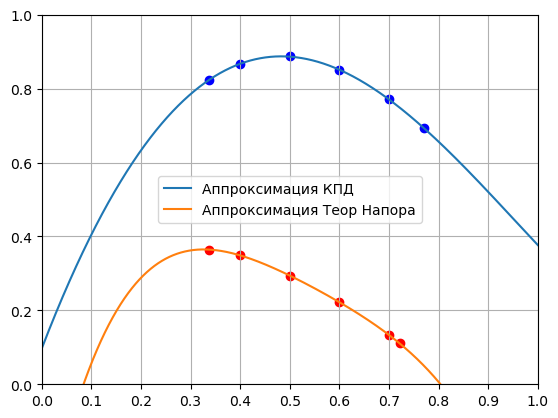

In [267]:
# График с учебника рис. 4

# Точки
x_η_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])       # точки по оси X для теоретического напора
η_dots = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])      # точки по оси Y для теоретического напора

x_Hт_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])    # точки по оси X для КПД
Hт_dots = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721]) # точки по оси Y для КПД

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(x_Hт_dots, Hт_dots, stepen)
poly = np.poly1d(coeffs)
coeffs1 = np.polyfit(x_η_dots, η_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000     # Число точек
x_Hт_dots_smooth = np.linspace(0, 1, smoothness)
Hт_dots_smooth = poly(x_Hт_dots_smooth)
x_η_dots_smooth = np.linspace(0, 1, smoothness)
η_dots_smooth = poly1(x_η_dots_smooth)

plt.plot(x_η_dots_smooth, η_dots_smooth, label="Аппроксимация КПД")
plt.plot(x_Hт_dots_smooth, Hт_dots_smooth, label="Аппроксимация Теор Напора")
plt.scatter(x_Hт_dots, Hт_dots, color="red")
plt.scatter(x_η_dots, η_dots, color="blue")
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.arange(0, 1.1, 0.1))  # Установка делений по оси X с шагом 0.1
plt.yticks(np.arange(0, 1.1, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()

Hт_x_line = x_Hт_dots_smooth    # Координаты X для линии теоретического напора
Hт_y_line = Hт_dots_smooth      # Координаты Y для линии теоретического напора
η_x_line = x_η_dots_smooth      # Координаты X для линии КПД
η_y_line = η_dots_smooth        # Координаты Y для линии КПД


In [268]:
Tа_полн = 288   # K
Pа_полн = 1.013 * 10**5  # Па
G_в = 58.7  # кг/с
π_к_полн = 18.2  # Степень повышения давления в компрессоре
n = 8600  # об/мин

R_в = 287.4  # Дж/(кг*К)
k = 1.4  # показатель адиабаты для воздуха
# Дж/(кг*К) удельная теплоемкость при постоянном давлении для воздуха
c_p = 1006

# 2. Выбор основных параметров компрессора и предварительный расчет проточной части по средней линии тока

## Предварительный расчет проточной части по средней линии тока

In [269]:
d1_отн = 0.4
c_а1_отн = 0.45
c_a2_отн = 0.3
Hт_ср_отн = 0.3
R_ср1 = 0.5
H_т1 = 0.2
D_type = 'D_к_const'

# Первое приближение

In [270]:
n = n / (60 / (2 * math.pi))  # Преобразуем обороты в радианы в секунду
print(f" n = {n}")

 n = 900.589894029074


In [271]:
def η_к_полн_def(π_к_полн, k, η_пол):
    η_к_полн = (((π_к_полн)**((k-1)/k)-1) / ((π_к_полн)**((k-1)/(k*η_пол))-1) - 0.02)
    return(η_к_полн)

def Tk_полн_def(π_к_полн, k, η_пол, Tа_полн):
    η_к_полн = η_к_полн_def(π_к_полн, k, η_пол)
    Tk_полн = Tа_полн * (1 + ((π_к_полн**((k-1)/k)-1) / η_к_полн))
    return(Tk_полн)

def a_кр_def(k, R_в, T):
    a_кр = np.sqrt((2*k/(k+1))*R_в*T)
    return(a_кр)

def ρ_полн_def(P_полн, T_полн, R_в):
    ρ_полн = P_полн / (T_полн * R_в)
    return(ρ_полн)

def U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн):
    U_k = np.cbrt((G_в * n**2)/(np.pi * c_а1_отн * ρ1_полн * (1 - d1_отн**2)))
    return(U_k)

def c_real_def(U_k1, c_а_отн):
    c_real = U_k1 * c_а_отн
    return(c_real)

def λ_def(c_real, a_кр):
    λ = c_real / a_кр
    return(λ)

def ε_gdf(k, λ):
    return (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def σ_in_gdf(ξ, k, ε, λ):
    return (1 / (1 + ξ * (k/(k+1)) * ε * λ**2))

def σ_out_gdf(ξ, k, ε, λ):
    return (1 - ξ * (k/(k+1)) * ε * λ**2)

def radius_отн(d_отн):
    return np.sqrt( (1 + d_отн**2) / 2)

def c_u_отн_def(r_ср_отн, R_ср, H_т):
    c_u_отн = r_ср_отн * (1 - R_ср) - (H_т / (2 * r_ср_отн))
    return(c_u_отн)

def q_gdf(k, λ):
    return ((k+1)/2)**(1/(k-1)) * λ * (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def F_tube(G_в, R_в, T, β, P, q):
    return (G_в * np.sqrt(R_в * T)) / (β * P * q)

def β_k_def(k):
    β = np.sqrt((2*k)/(k+1)) * (2 / (k+1))**(1/(k-1))
    return(β)


In [272]:
# 1. Импорт и очистка данных
# skipinitialspace=True убирает пробелы после запятых в CSV
df = pd.read_csv('resources/air_param.csv', skipinitialspace=True)

# Очищаем названия колонок от случайных пробелов
df.columns = df.columns.str.strip()

# Принудительно переводим важные колонки в числа. 
# Ошибки (буквы) станут NaN, которые мы потом удалим.
cols_to_fix = ['p_bar', 'T_K', 'c_p']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols_to_fix)

def c_p_def(P_poln_Pa, T1_poln_K):
    """
    Находит c_p:
    P_poln_Pa: Давление на входе в Паскалях (Pa)
    T1_poln_K: Температура на входе в Кельвинах (K)
    """
    # Перевод входного давления из Па в бары для сопоставления с таблицей
    P_poln_bar = P_poln_Pa / 1e5
    
    # Получаем список уникальных давлений из таблицы (они уже в барах)
    available_pressures = df['p_bar'].unique()
    
    # 2. Поиск самого близкого давления в барах
    closest_p = available_pressures[np.abs(available_pressures - P_poln_bar).argmin()]
    
    # Фильтруем данные для выбранной изобары
    data_p = df[df['p_bar'] == closest_p].sort_values('T_K')
    
    # 3. Линейная интерполяция по температуре
    # np.interp(целевая_T, список_T_из_таблицы, список_cp_из_таблицы)
    cp_value = np.interp(T1_poln_K, data_p['T_K'], data_p['c_p'])
    
    return cp_value

In [273]:
# Определим адиабатический КПД
η_пол = 0.90 # Политропический КПД компрессора из рис.1

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

#  Ожидаемый КПД
η_к_полн = η_к_полн_def(π_к_полн, k, η_пол)
π_к_полн_0 = π_к_полн
η_к_полн_0 = η_к_полн

# Температура на выходе из ЛА компрессора
Tk_полн = Tk_полн_def(π_к_полн, k, η_пол, Tа_полн)
T2_полн = Tk_полн

# Критическая скорость звука во входном и выходном патрубках
a_кр_вх = a_кр_def(k, R_в, Tа_полн)
a_кр_вых = a_кр_def(k, R_в, Tk_полн)

# Плотность рабочего тела по заторможенным параметрам
ρ1_полн = ρ_полн_def(Pа_полн, Tа_полн, R_в)

# Окружная скорость реальная на конце лопатки
U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн)
print(U_k1)
print(G_в, n, c_а1_отн, ρ1_полн, d1_отн)
# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = c_real_def(U_k1, c_а1_отн)
c_вых = c_real_def(U_k1, c_a2_отн)

# Приведенные скорости в данных сечениях
λ_вх = λ_def(c_вх, a_кр_вх)
λ_вых = λ_def(c_вых, a_кр_вых)

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)


π_ла_полн = π_к_полн / (σ_вх * σ_вых)
η_ла_полн = ((π_ла_полн)**((k-1)/k)-1) / ((π_ла_полн)**((k-1)/(k*η_пол))-1)

π_ла_полн_0 = π_ла_полн
η_ла_полн_0 = η_ла_полн

print(f"""
σ_вх * σ_вых = {σ_вх * σ_вых}
π_ла_полн = {π_ла_полн}
η_к_полн = {η_к_полн}
η_ла_полн = {η_ла_полн}
""")

319.9681800746992
58.7 900.589894029074 0.45 1.223855640609294 0.4

σ_вх * σ_вых = 0.9911087573907559
π_ла_полн = 18.363272309200717
η_к_полн = 0.8338097173818555
η_ла_полн = 0.853654218772678



In [274]:
U_k1_before = U_k1 * 100
number = 1
while True:
    # Осевая скорость на переферии РК
    c_а1 = c_real_def(U_k1, c_а1_отн)
    
    # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
    c_вх = c_real_def(U_k1, c_а1_отн)
    c_вых = c_real_def(U_k1, c_a2_отн)

    # Пренебрегая теплообменом в трубках:
    T1_полн = Tа_полн


    # Температура на выходе из ЛА компрессора
    Tk_полн = Tk_полн_def(π_к_полн, k, η_пол, Tа_полн)
    T2_полн = Tk_полн

    # Критическая скорость звука во входном и выходном патрубках
    a_кр_вх = a_кр_def(k, R_в, Tа_полн)
    a_кр_вых = a_кр_def(k, R_в, Tk_полн)

    # Приведенные скорости в данных сечениях
    λ_вх = λ_def(c_вх, a_кр_вх)
    λ_вых = λ_def(c_вых, a_кр_вых)

    # Коэффициент потерь полного давления во входном и выходном патрубках
    ξ_вх = 0.05     # Для входного патрубка
    ξ_вых = 0.15    # Для выходного патрубка

    # ГДФ плотности для входного и выходного патрубков
    ε_вх = ε_gdf(k, λ_вх)       
    ε_вых = ε_gdf(k, λ_вых)
    #  !!!!!!!!Перепроверить верность выражений в функции!

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
    σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

    # Полные давления на входе и выходе из лопаточного аппарата
    P1_полн = σ_вх * Pа_полн
    Pк_полн = Pа_полн * π_к_полн
    P2_полн = Pк_полн / σ_вых
    # Средний радиус на входе в первую степень
    r_ср1_отн = radius_отн(d1_отн)

    # Безразмерная окружная составляющая абсолютной скорости на входе
    c_1u_отн = c_u_отн_def(r_ср1_отн, R_ср1, H_т1)

    # Абсолютная скорость: 
    c1 = U_k1 * math.sqrt(c_а1_отн**2 + c_1u_отн**2)

    # Приведенная скорость:
    λ1 = λ_def(c1, a_кр_вх)

    # ГДФ плотности
    ε = (1 - ((k-1)/(k+1)) * λ1**2)**(1/(k-1))
    # !!!!!!!!Перепроверить верность выражения!!!!!!!

    # Плотность рабочего тела перед РК
    ρ1 = ρ_полн_def(P1_полн, T1_полн, R_в) * ε
    # !!!!!!!!Перепроверить верность выражения!!!!!!!

    # Перерасчет окружной скорости конца рабочей лопатки
    U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
    print(f"""
    U_k1_before = {U_k1_before}  м/с
    U_k1 = {U_k1} м/с
((U_k1 - U_k1_before)/U_k1)*100 = {abs((U_k1 - U_k1_before)/U_k1)*100:.6f} % 
          """)
    loss_percenteg = 0.000000001
    # Цикл, который проверяет разницу между предыдущим и нынешним числом. Нужен для проведения итераций
    if abs((U_k1 - U_k1_before)/U_k1)*100 <= loss_percenteg:
        print(f"ИТОГ: U_k1 = {U_k1:.2f} м/с, число итераций {number}")  # Вывод итога вычислений
        break
    else:
        U_k1_before = U_k1  # Запись предыдущего числа для последующего сравнения в дальнейшем
        number = number + 1 # Подсчет числа итераций
    


    U_k1_before = 31996.81800746992  м/с
    U_k1 = 333.63450245775124 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 9490.380423 % 
          

    U_k1_before = 333.63450245775124  м/с
    U_k1 = 334.87940394444325 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.371746 % 
          

    U_k1_before = 334.87940394444325  м/с
    U_k1 = 334.9958456714842 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.034759 % 
          

    U_k1_before = 334.9958456714842  м/с
    U_k1 = 335.0067631937102 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.003259 % 
          

    U_k1_before = 335.0067631937102  м/с
    U_k1 = 335.0077870451258 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.000306 % 
          

    U_k1_before = 335.0077870451258  м/с
    U_k1 = 335.0078830645102 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.000029 % 
          

    U_k1_before = 335.0078830645102  м/с
    U_k1 = 335.00789206946956 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.000003 % 
          

    U_k1_before = 335.00789206946956  м/с
    U_k1 = 335.0078929139

In [275]:
# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = c_real_def(U_k1, c_а1_отн)
c_вых = c_real_def(U_k1, c_a2_отн)

# Приведенные скорости в данных сечениях
λ_вх = λ_def(c_вх, a_кр_вх)
λ_вых = λ_def(c_вых, a_кр_вых)

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

# Полные давления на входе и выходе из лопаточного аппарата
P1_полн = σ_вх * Pа_полн
P2_полн = Pа_полн * π_к_полн / σ_вых

# Степень повышения полного давления лопаточного аппарата
π_ла_полн = P2_полн / P1_полн
π_к_полн = π_ла_полн * (σ_вых * σ_вх)

# КПД лопаточного аппарата
η_ла = σ_вых * σ_вх  # Должно быть 1

# Коэффициент C определяется из графика на рис. 7
C = 0.98  # Надо написать функцию для определения C по графику, а не брать константное значение
# !!!!!!!!
# !!!!!!!!

η_ла_полн = η_к_полн / C
η_к_полн = η_ла_полн * ((π_к_полн**((k-1)/k)-1)/(π_ла_полн**((k-1)/k)-1))


β = β_k_def(k)

# Приведенная плотность потока массы
q_вх = q_gdf(k, λ_вх)
q_вых = q_gdf(k, λ_вых)
# Кольцевые площади на выходе из входного патрубка и на входе в выходной патрубок
F_вх = F_tube(G_в, R_в, T1_полн, β, P1_полн, q_вх)
F_вых = F_tube(G_в, R_в, T2_полн, β, P2_полн, q_вых)

In [276]:
# Наружный диаметр ротора:
D_к1 = 2 * U_k1 / n

# Внутренний диаметр
D_вт1 = D_к1 * d1_отн

# Средний диаметр
D_ср1 = D_к1 * r_ср1_отн

# Высота лопатки РК 1-й ступени:
h_1 = (1/2) * D_к1 * (1 - d1_отн)

In [277]:
# Выбор формы проточной части лопаточного аппарата. 

if D_type == 'D_к_const':
    # Dк = const

    D_к = D_к1
    # Диаметр втулки лопаток последнйей ступени:
    D_вт_n = math.sqrt(D_к**2 - ((4 * F_вых) / math.pi))
    # Относительный диаметр втулки рабочего колеса последней ступени:
    d_n_отн = D_вт_n / D_к
    h_n = (1/2) * D_к * (1 - d_n_отн)

    print(f"""
    Dк = const      

    D_вт_n = {D_вт_n}
    d_n_отн = {d_n_отн}
    h_n = {h_n}
    """)

elif D_type == 'D_вт_const':
    # Dвт = const

    D_вт = D_вт1
    D_к_n = math.sqrt(D_вт**2 + (4 * F_вых / math.pi))
    d_n_отн = D_вт / D_к_n
    h_n = (1/2) * (D_к_n - D_вт)

    print(f"""
    Dвт = const      

    D_к_n = {D_к_n}
    d_n_отн = {d_n_отн}
    h_n = {h_n}
    """)

else:
    # Dср = const
    
    D_ср = D_ср1
    D_к_n = math.sqrt(D_ср**2 + (2 * F_вых / math.pi))
    D_вт_n = math.sqrt(D_ср**2 - ((2 * F_вых) / math.pi))
    h_n = (1/2)*(D_к_n - D_вт_n)
    d_n_отн = d1_отн

    print(f"""
    Dср = const      

    D_к_n = {D_к_n}
    D_вт_n = {D_вт_n}
    h_n = {h_n}
    """)


    Dк = const      

    D_вт_n = 0.6835587135571299
    d_n_отн = 0.9187933810900832
    h_n = 0.030207820983934777
    


In [278]:
# Окружная скорость концов рабочих лопаток "средней" ступени:
ρ2 = ρ_полн_def(P2_полн, T2_полн, R_в)
U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
U_k2 = U_k_def(G_в, n, c_a2_отн, ρ2, d_n_отн)
U_к_ср = (U_k1 + U_k2) / 2
# Теоретический напор "средней" ступени:
Hт_ср = Hт_ср_отн * (U_к_ср**2)

# Адиабатический напор компрессора по параметрам затарможенного потока
H_ад_к_полн = (k*R_в)/(k-1) * Tа_полн*((π_к_полн ** ((k-1)/k))-1)

# Сумма теоретических напоров по ступеням:
H_тк = H_ад_к_полн / η_к_полн

# Число ступеней компрессора:
z = H_тк / Hт_ср
print(f"z = {z} Не округленное")

z = math.ceil(z)
print(f"z = {z}")

print(f"η_ла = {η_ла}")
print(f"π_к_полн = {π_к_полн}")

z = 13.195131748269294 Не округленное
z = 14
η_ла = 0.9903188073087799
π_к_полн = 18.2


In [279]:
N = z   # Число ступеней компрессора
N_list = np.linspace(1, N, N)   # Массив от 1 до N для итерации по ступеням

Hт_x_i_отн = []
Hт_i_отн = []

c_a_i_отн = np.linspace(c_а1_отн, c_a2_отн, N) # Линейно изменяющийся коэффициент расхода от первой до последней ступени

In [280]:
def find_nearest(c_a_отн, x_line, y_line):
    x_result = []
    y_result = []

    for i in range(len(c_a_i_отн)):
        index = np.abs(x_line - c_a_i_отн[i]).argmin() # Находим индекс ближайшего значения в x_line к c_a_отн[i]
        x_result.append(x_line[index])    # Добавляем найденное значение в результат
        y_result.append(y_line[index])  # Добавляем соответствующее значение y_line в результат
    return x_result, y_result

Hт_x_i_отн, Hт_i_отн = find_nearest(c_a_i_отн, Hт_x_line, Hт_y_line)
η_x_i_отн, η_ад_полн_i = find_nearest(c_a_i_отн, η_x_line, η_y_line)

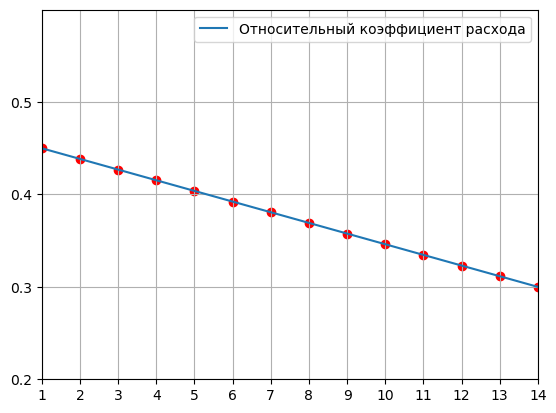

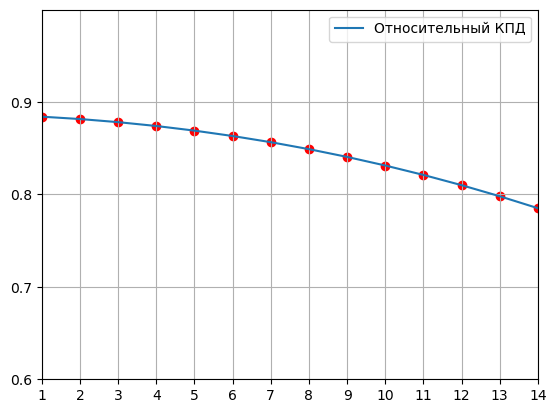

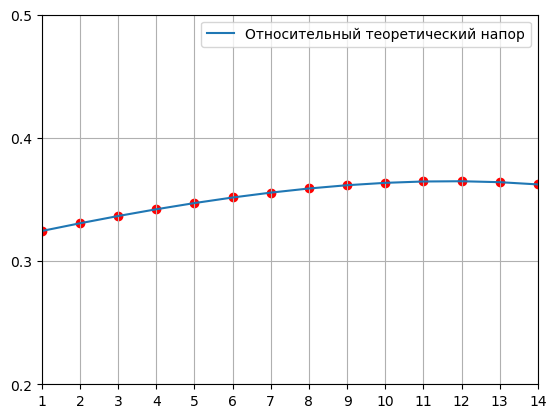

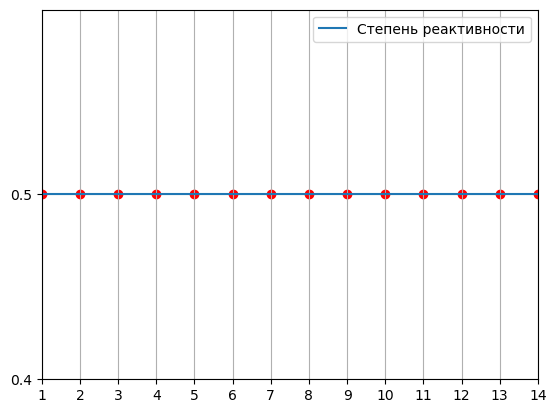

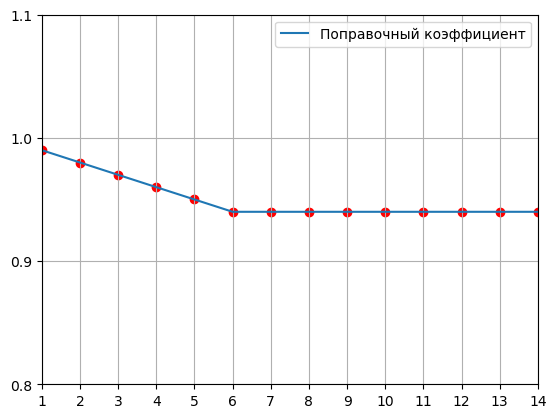

In [281]:
def plot_results(x, y, label_name):
    ylim_min = math.floor(min(y)*10)/10-0.1
    ylim_max = math.ceil(max(y)*10)/10+0.1
    plt.plot(x, y, label=label_name)
    plt.scatter(x, y, color="red")
    plt.xlim(1,max(x))
    plt.ylim(ylim_min, ylim_max)
    plt.xticks(np.arange(1, max(x)+1, 1))
    plt.yticks(np.arange(ylim_min, ylim_max, 0.1))
    plt.grid(True) # Добавление сетки
    plt.legend()
    plt.show()

R_ср1_list = np.linspace(R_ср1, R_ср1, N)  # Создаем массив из N элементов, все равные R_ср1
Kh_i = np.concatenate([
    np.linspace(0.99, 0.94, 6),
    np.full((N-6), 0.94)
])

plot_results(N_list, c_a_i_отн, "Относительный коэффициент расхода")
plot_results(N_list, η_ад_полн_i, "Относительный КПД")
plot_results(N_list, Hт_i_отн, "Относительный теоретический напор")
plot_results(N_list, R_ср1_list, "Степень реактивности")
plot_results(N_list, Kh_i, "Поправочный коэффициент")

In [282]:
# Расчет ВНА
# Коэффициент сохранения полного давления в ВНА
print(f"""
    σ_вх = {σ_вх:.4f} - коэффициент сохранения полного давления в ВНА
    Pa_полн = {Pа_полн:.2f} Па - полное давление на входе в ВНА
    P1_полн = {P1_полн:.2f} Па - полное давление на выходе из ВНА
    c_1u_отн = {c_1u_отн:.4f} - безразмерная окружная составляющая абсолютной скорости на выходе из ВНА""")

# Направление абсолютной скорости на входе в ВНА
α_1_вна = math.radians(90)
α_2_вна = (math.atan(c_а1_отн / c_1u_отн))

print(f"""
    α_1_вна = {math.degrees(α_1_вна):.2f}° - направление абсолютной скорости на входе в ВНА
    α_2_вна = {math.degrees(α_2_вна):.2f}° - направление абсолютной скорости на выходе из ВНА
      """)


    σ_вх = 0.9938 - коэффициент сохранения полного давления в ВНА
    Pa_полн = 101300.00 Па - полное давление на входе в ВНА
    P1_полн = 100674.72 Па - полное давление на выходе из ВНА
    c_1u_отн = 0.2495 - безразмерная окружная составляющая абсолютной скорости на выходе из ВНА

    α_1_вна = 90.00° - направление абсолютной скорости на входе в ВНА
    α_2_вна = 61.00° - направление абсолютной скорости на выходе из ВНА
      


# 3. Поступенчатый расчет значений для каждой ступени

In [283]:
# Коэффициент расхода на выходе из ступени
c_a_i_отн_plus_1 = np.concatenate((c_a_i_отн[1:], [c_a_i_отн[-1]]))

# Давление перед ступенями по длине компрессора
P1_полн_i = np.linspace(P1_полн, P2_полн, N)

# Температура перед ступенью по длине компрессора
T1_полн_i = np.linspace(T1_полн, T2_полн, N)

# Диаметры относительные по длине компрессора
d1_отн_i = np.linspace(d1_отн, d_n_отн, N)

# Окружные скорости по длине компрессора
U_k_i = np.linspace(U_k1, U_k2, N)

# Начало расчета из Бекнева
# 1. Теоретический напор для i-й ступени:
Hт_i = Hт_i_отн * (U_k_i**2)

# 2. Действительная работа сжатия для i-й ступени:
L_z_i = Kh_i * Hт_i

# 3. Адиабатическая работа сжатия для i-й ступени:
H_ад_i = L_z_i * η_ад_полн_i

# Генерация списка c_p для каждой ступени
# Расчет списка c_p
try:
    c_p_i = [c_p_def(p, t) * 1000 for p, t in zip(P1_полн_i, T1_полн_i)]
    
    print("Результаты расчета:")
    for p, t, cp in zip(P1_полн_i, T1_полн_i, c_p_i):
        print(f"P = {p:10.0f} Па ({p/1e5:6.1f} бар), T = {t:6.1f} К -> c_p = {cp:.4f}")
except Exception as e:
    print(f"Произошла ошибка при расчете: {e}")
    
# 4. Повышение полной температуры в ступени:
ΔT_полн_i = L_z_i / c_p_i # с_р в каждой ступени разный т.к. меняется температура

# 5. Полная температура на выходе из ступени:
T3_полн_i = T1_полн_i + ΔT_полн_i
T1_полн_i_plus_1 = T3_полн_i    # Температура на выходе становится температурой на входе в следующую ступень

# 6. Степень повышения полного давления:
π_полн_i = (1 + (H_ад_i / (c_p * T1_полн_i)))**(k/(k-1))
   
# 7. Полное давление на выходе из ступени:
P3_полн_i = P1_полн_i * π_полн_i 
P1_полн_i_plus_1 = P3_полн_i
    
# 8. Критическая скорость потока на входе и выходе:
a_кр_1_i = np.sqrt((2*k/(k+1))*R_в*T1_полн_i)
a_кр_3_i = np.sqrt((2*k/(k+1))*R_в*T3_полн_i)
    
# 9. Средний радиус на входе в i-ю ступень:
r_ср1_отн_i = np.sqrt( (1 + d1_отн_i**2) / 2)
    
# 10. Безразмерная окружная составляющая абсолютной скорости на входе в i-ю ступень:
c_u1_отн_i = r_ср1_отн_i * (1 - R_ср1) - (Hт_i_отн / (2 * r_ср1_отн_i))
    
# 11. Направление абсолютной скорости на входе
α_1_i = np.arctan(c_a_i_отн / c_u1_отн_i)
    
# 12. Приведенная скорость на входе
c_a1_i = c_a_i_отн * U_k_i
λ_1_i = c_a1_i / (np.sin(α_1_i) * a_кр_1_i)
    
# 13. ГДФ расхода
q_1_i = q_gdf(k, λ_1_i)

# 14. Кольцевая площадь на входе в ступень
F_1_i = (G_в * np.sqrt(R_в * T1_полн_i)) / (β * P1_полн_i * q_1_i * np.sin(α_1_i))

# 15. Кольцевая площадь на выходе из ступени F3
c_a3_отн_i = c_a_i_отн_plus_1
c_a3_i = c_a3_отн_i * U_k_i
λ_3_i_0 = c_a3_i / (np.sin(α_1_i) * a_кр_3_i)

q_3_i = q_gdf(k, λ_3_i_0)
F_3_i_0 = F_1_i * ((q_1_i * P1_полн_i) / (q_3_i * P3_полн_i)) * np.sqrt(T3_полн_i / T1_полн_i)
    
# 16. Относительный диаметр втулки на выходе из ступени d3отн в первом прибляж для принятой ф. проточной части Dk = const
if D_type == 'D_к_const':
    D_вт3_i = np.sqrt(D_к**2 - ((4 * F_3_i_0) / np.pi))
    d3_отн_i_0 = D_вт3_i / D_к1
elif D_type == 'D_вт_const':
    D_к3_i = np.sqrt(D_вт1**2 + ((4 * F_3_i_0)/ np.pi))
    d3_отн_i_0 = D_вт / D_к3_i
else:
    d3_отн_i_0 = np.linspace(d1_отн, d1_отн, N)

# Относительный средний радиус на выходе из ступени
r_ср3_отн_i = np.sqrt( (1 + d3_отн_i_0**2) / 2)

# 17. Безразмерная окружная состовляющая абсолютной скорости на выходе
R_ср1_i_plus_1 = np.concatenate((R_ср1_list[1:], [R_ср1_list[-1]]))
Hт_i_отн_plus_1 = np.concatenate((Hт_i_отн[1:], [Hт_i_отн[-1]]))

c_3u_отн_i = r_ср3_отн_i * (1 - R_ср1_i_plus_1) - (Hт_i_отн / (2 * r_ср3_отн_i))

# 18. Направление потока в абсолютном движении после НА
α_3_i = np.atan(c_a3_отн_i / c_3u_отн_i)

# 19. Приведенная скорость на выходе
λ_3_i = c_a3_i / (np.sin(α_3_i) * a_кр_3_i)

# 20. Действительная кольцевая площадь на выходе из ступени
F_3_i = F_3_i_0 * ((q_gdf(k, λ_3_i_0)) / (q_gdf(k, λ_3_i)))
F_1_i_plis_1 = np.concatenate((F_3_i[1:], [F_3_i[-1]]))

# 21. Действительный относительный диаметр втулки d_3_отн подсчитывется в завис от типа проточн части.
if D_type == 'D_к_const':
    D_вт3_i = np.sqrt(D_к**2 - ((4 * F_3_i) / np.pi))
    d3_отн_i = D_вт3_i / D_к1
elif D_type == 'D_вт_const':
    D_к3_i = np.sqrt(D_вт1**2 + ((4 * F_3_i)/ np.pi))
    d3_отн_i = D_вт / D_к3_i
else:
    d3_отн_i = np.linspace(d1_отн, d1_отн, N)

# 22. Средний радиус на выходе из ступени
r_ср3_отн_i = np.sqrt( (1 + d3_отн_i**2) / 2)

# 23. Средний радиус на выходе из рабочего колеса
r_ср2_отн_i = (r_ср1_отн_i + r_ср3_отн_i) / 2

# 24. Безразмерная окружная составляющая абсолютной скорости на выходе из рабочего колеса
c_u2_отн_i = (1 / r_ср2_отн_i) * (Hт_i_отн + c_u1_отн_i * r_ср1_отн_i)

# 25. Углы потока в относительном движении
β_1_i = np.atan((c_a_i_отн / (r_ср1_отн_i- c_u1_отн_i)))
c_a2_отн_i = (c_a_i_отн + c_a_i_отн_plus_1) / 2
β_2_i = np.atan((c_a2_отн_i / (r_ср2_отн_i- c_u2_отн_i)))
    
# 26. Направление потока в абсолютном движении после рабочего колеса
α_2_i = np.atan(c_a2_отн_i / c_u2_отн_i)
    
# 27. Углы поворота потока в средних сечениях лопаток РК и НА
ε_рк_i = β_2_i - β_1_i
ε_на_i = α_3_i - α_2_i

# 28. Относительная скорость на среднем радиусе на входе в РК
W_1_i = c_a1_i / np.sin(β_1_i)

# 29. Абсолютная скорость на среднем радиусе на входе в НА
c_a2_i = c_a2_отн_i * U_k_i
c_2_i = c_a2_i / np.sin(α_2_i)

# 30. Число Маха по относительной скорости на входе в РК
# ГДФ температуры на входе в РК
τ_1_i = (1 - (λ_1_i**2)*((k-1)/(k+1)))
# Статическая температура перед РК
T_1_i = T1_полн_i * τ_1_i
# Скорость звука на входе в РК
a_1_i = a_кр_def(k, R_в, T_1_i)

M_w1_i = W_1_i / a_1_i

# 31. Число Маха по абсолютной скорости на входе в НА
# Приведенная скорость перед НА
λ_c2_i = c_2_i / a_кр_3_i
# Статическая температура перед НА
T2_полн_i = T3_полн_i
τ_2_i = (1 - (λ_c2_i**2)*((k-1)/(k+1)))
T_2_i = T2_полн * τ_2_i
# Скорость звука на входе в НА
a_2_i = a_кр_def(k, R_в, T_2_i)

M_c2_ср_i = c_2_i / a_2_i



# Надо перепроверить, нужно ли все, что ниже!!!!!!!!!!
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Абсолютная скорость на входе в РК
c_1_i = U_k_i * np.sqrt(c_a_i_отн**2 + c_u1_отн_i**2)
# Плотность заторможенного потока на выходе из ступени
ε_3_i = (1 - (k-1)/(k+1)*λ_3_i**2)**(1/(k-1))
ρ3_i = ((P3_полн_i) / (R_в * T3_полн_i)) * ε_3_i
# Относительная скорость на среднем радиусе на входе в НА
W_2_i = c_a2_i / np.sin(β_2_i)

    
# Высота лопаток рабочего колеса
D_вт1_i = D_к * d1_отн_i
h_рк_i = 0.5 * (D_к - D_вт1_i)
    
# Относительный диаметр втулки на выходе из РК
d2_отн_i = np.sqrt(2 * (r_ср2_отн_i**2) - 1)
D_ср_1 = D_к * r_ср1_отн_i
D_ср_2 = D_к * r_ср2_отн_i
D_ср_3 = D_к * r_ср3_отн_i
    
# Периферийный диаметр на выходе из РК
D_вт2_i = D_к * d2_отн_i
D_вт1_i = D_к * d1_отн_i
    
# Высота лопаток НА
h_на_i = 0.5 * (D_к - D_вт2_i)
h_на_3_i = 0.5 * (D_к - D_вт3_i)

Результаты расчета:
P =     100675 Па (   1.0 бар), T =  288.0 К -> c_p = 1006.0000
P =     235253 Па (   2.4 бар), T =  322.3 К -> c_p = 1010.0000
P =     369831 Па (   3.7 бар), T =  356.6 К -> c_p = 1014.7921
P =     504409 Па (   5.0 бар), T =  390.9 К -> c_p = 1016.2721
P =     638988 Па (   6.4 бар), T =  425.2 К -> c_p = 1021.0242
P =     773566 Па (   7.7 бар), T =  459.5 К -> c_p = 1026.5204
P =     908144 Па (   9.1 бар), T =  493.8 К -> c_p = 1033.0085
P =    1042723 Па (  10.4 бар), T =  528.1 К -> c_p = 1039.6207
P =    1177301 Па (  11.8 бар), T =  562.4 К -> c_p = 1046.7288
P =    1311879 Па (  13.1 бар), T =  596.7 К -> c_p = 1055.3408
P =    1446457 Па (  14.5 бар), T =  631.0 К -> c_p = 1062.8210
P =    1581036 Па (  15.8 бар), T =  665.3 К -> c_p = 1070.3671
P =    1715614 Па (  17.2 бар), T =  699.6 К -> c_p = 1077.9132
P =    1850192 Па (  18.5 бар), T =  733.9 К -> c_p = 1087.1375


In [284]:
π_ла_полн = P2_полн / P1_полн
η_ла_полн = (T1_полн * (π_ла_полн**((k-1)/k) - 1)) / (T2_полн - T1_полн)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

π_к_полн = π_ла_полн * σ_вх * σ_вых

# Есть два варианта расчета кпд из учебника, будто 2 вариант круче
# !!!!!!!!!!!!!!!!!!!!!!!!!!
Tk_полн_new = T2_полн
T1_полн_new = Tа_полн

η_к_полн = ((T1_полн_new * (π_к_полн**((k-1)/k) - 1)) / (Tk_полн_new - T1_полн_new)) - 0.02
η_к_полн = np.sum(H_ад_i) / np.sum(L_z_i) - 0.02
N_к = G_в * np.sum(L_z_i)
print(f"""
π_ла_полн = {π_ла_полн}
η_ла_полн = {η_ла_полн}

π_ла_полн_0 = {π_ла_полн_0}
η_ла_полн_0 = {η_ла_полн_0}

σ_вх  = {σ_вх}
σ_вых = {σ_вх}

π_к_полн = {π_к_полн:.4f}
η_к_полн = {η_к_полн:.4f}

π_к_полн_0 = {π_к_полн_0:.4f}
η_к_полн_0 = {η_к_полн_0:.4f}

N_к = {N_к}
""")


π_ла_полн = 18.377920186590245
η_ла_полн = 0.8379282711041244

π_ла_полн_0 = 18.363272309200717
η_ла_полн_0 = 0.853654218772678

σ_вх  = 0.99382749245897
σ_вых = 0.99382749245897

π_к_полн = 18.2000
η_к_полн = 0.8254

π_к_полн_0 = 18.2000
η_к_полн_0 = 0.8338

N_к = 30665899.5266035



In [285]:
# Список всех имён переменных‑списков
list_names = [
    "c_a_i_отн","c_a_i_отн_plus_1","P1_полн_i",
    "T1_полн_i","d1_отн_i","U_k_i","Hт_i","L_z_i","H_ад_i",
    "ΔT_полн_i","T3_полн_i","T1_полн_i_plus_1","π_полн_i",
    "P3_полн_i","P1_полн_i_plus_1","a_кр_1_i","a_кр_3_i",
    "r_ср1_отн_i","c_u1_отн_i","α_1_i","c_a1_i","λ_1_i",
    "q_1_i","F_1_i","c_a3_отн_i","c_a3_i","λ_3_i_0","q_3_i",
    "F_3_i_0","d3_отн_i_0","r_ср3_отн_i","c_3u_отн_i","α_3_i",
    "λ_3_i","F_3_i","F_1_i_plis_1","d3_отн_i","r_ср2_отн_i",
    "c_u2_отн_i","β_1_i","c_a2_отн_i","β_2_i","α_2_i","ε_рк_i",
    "ε_на_i","W_1_i","c_a2_i","c_2_i","τ_1_i","T_1_i","a_1_i",
    "M_w1_i","λ_c2_i","T2_полн_i","τ_2_i","T_2_i","a_2_i","M_c2_ср_i"
]

# Формируем словарь {короткое_имя: список_значений}
data = {}
for name in list_names:
    # получаем объект по имени (globals())
    lst = globals().get(name, [])
    data[name.rstrip('_list')] = lst          # убираем суффикс _list для названия колонки

# ──────────────────────────────────────────────────────
# 3️⃣ Выравниваем длину всех списков (чтобы DataFrame не ругался)
# ──────────────────────────────────────────────────────
"""
max_len = max(len(col) for col in data.values())
for key, col in data.items():
    if len(col) < max_len:
        data[key] = col + [np.nan]*(max_len - len(col))
"""
# ──────────────────────────────────────────────────────
# 4️⃣ Создаём DataFrame
# ──────────────────────────────────────────────────────
df = pd.DataFrame(data)

# ──────────────────────────────────────────────────────
# 5️⃣ Настраиваем вывод (по желанию)
# ──────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)   # показывать все столбцы
pd.set_option('display.max_rows',    200)   # ограничить количество строк (чтобы не «зависать»)
pd.set_option('display.float_format', lambda x: f'{x: .4g}')

# ──────────────────────────────────────────────────────
# 6️⃣ Выводим таблицу в ячейке ноутбука
# ──────────────────────────────────────────────────────
display(df)            # либо просто написать `df` в отдельной ячейке

# ──────────────────────────────────────────────────────
# 7️⃣ (Опционально) сохраняем в файл
# ──────────────────────────────────────────────────────
df.to_excel('расчет_ступеней.xlsx', index=False)
# df.to_csv('расчет_ступеней.csv', index=False)

,c_a_i_отн,c_a_i_отн_plus_1,P1_полн,T1_полн,d1_отн,U_k,Hт,L_z,H_ад,ΔT_полн,T3_полн,T1_полн_i_plus_1,π_полн,P3_полн,P1_полн_i_plus_1,a_кр_1,a_кр_3,r_ср1_отн,c_u1_отн,α_1,c_a1,λ_1,q_1,F_1,c_a3_отн,c_a3,λ_3_i_0,q_3,F_3_i_0,d3_отн_i_0,r_ср3_отн,c_3u_отн,α_3,λ_3,F_3,F_1_i_plis_1,d3_отн,r_ср2_отн,c_u2_отн,β_1,c_a2_отн,β_2,α_2,ε_рк,ε_на,W_1,c_a2,c_2,τ_1,T_1,a_1,M_w1,λ_c2,T2_полн,τ_2,T_2,a_2,M_c2_ср
0,0.45,0.4385,1.007e+05,288,0.4,335,3.641e+04,3.605e+04,3.187e+04,35.83,323.8,323.8,1.441,1.451e+05,1.451e+05,310.8,329.5,0.7616,0.1678,1.214,150.8,0.5177,0.7285,0.3589,0.4385,146.9,0.4757,0.6817,0.2823,0.5922,0.8282,0.2135,1.118,0.4958,0.2731,0.1291,0.6097,0.7949,0.5689,0.6485,0.4442,1.1,0.6629,0.4518,0.4547,249.6,148.8,241.8,0.9553,275.1,303.7,0.8218,0.7338,323.8,0.9102,668,473.3,0.5109
1,0.4385,0.4269,2.353e+05,322.3,0.4399,334.9,3.708e+04,3.634e+04,3.204e+04,35.98,358.3,358.3,1.391,3.272e+05,3.272e+05,328.7,346.6,0.7725,0.1722,1.197,146.8,0.4798,0.6864,0.1736,0.4269,143,0.4431,0.6432,0.1404,0.8228,0.9228,0.2773,0.9948,0.4918,0.1291,0.09293,0.8385,0.8477,0.5471,0.6308,0.4327,0.9637,0.6692,0.3328,0.3256,248.9,144.9,233.6,0.9616,309.9,322.4,0.7722,0.6739,358.3,0.9243,678.4,476.9,0.4897
2,0.4269,0.4154,3.698e+05,356.6,0.4798,334.7,3.771e+04,3.658e+04,3.212e+04,36.04,392.6,392.6,1.35,4.993e+05,4.993e+05,345.8,362.8,0.7843,0.1776,1.177,142.9,0.4476,0.6486,0.1239,0.4154,139,0.415,0.6087,0.1026,0.874,0.945,0.2904,0.9607,0.4675,0.09293,0.07707,0.8867,0.8647,0.5503,0.6132,0.4212,0.9296,0.6532,0.3164,0.3075,248.3,141,232,0.9666,344.7,340,0.7304,0.6393,392.6,0.9319,683.9,478.9,0.4844
3,0.4154,0.4038,5.044e+05,390.9,0.5197,334.6,3.829e+04,3.676e+04,3.213e+04,36.17,427.1,427.1,1.316,6.64e+05,6.64e+05,362,378.4,0.7969,0.1838,1.154,139,0.4198,0.6146,0.1014,0.4038,135.1,0.3905,0.5775,0.08565,0.8961,0.9546,0.2946,0.9405,0.442,0.07707,0.06855,0.907,0.8758,0.5579,0.5955,0.4096,0.9108,0.6334,0.3153,0.3072,247.8,137,231.6,0.9706,379.4,356.7,0.6946,0.6119,427.1,0.9376,688.1,480.3,0.4821
4,0.4038,0.3923,6.39e+05,425.2,0.5596,334.4,3.882e+04,3.688e+04,3.205e+04,36.12,461.3,461.3,1.288,8.228e+05,8.228e+05,377.6,393.3,0.8103,0.191,1.129,135.1,0.3957,0.5842,0.0888,0.3923,131.2,0.369,0.5496,0.07635,0.9079,0.9598,0.2958,0.9247,0.4178,0.06855,0.06359,0.9178,0.885,0.567,0.5778,0.3981,0.8967,0.6121,0.3189,0.3126,247.3,133.1,231.7,0.9739,414.1,372.6,0.6635,0.5891,461.3,0.9422,691.5,481.5,0.4812
5,0.3923,0.3808,7.736e+05,459.5,0.5995,334.3,3.929e+04,3.693e+04,3.188e+04,35.98,495.5,495.5,1.263,9.77e+05,9.77e+05,392.5,407.6,0.8245,0.199,1.101,131.1,0.3746,0.557,0.08107,0.3808,127.3,0.3501,0.5246,0.07078,0.915,0.9627,0.2958,0.9104,0.3954,0.06359,0.06056,0.924,0.8936,0.5771,0.5602,0.3865,0.8846,0.5902,0.3244,0.3202,246.8,129.2,232.2,0.9766,448.8,387.9,0.6362,0.5696,495.5,0.9459,694.2,482.5,0.4812
6,0.3808,0.3692,9.081e+05,493.8,0.6394,334.1,3.97e+04,3.731e+04,3.196e+04,36.12,529.9,529.9,1.244,1.13e+06,1.13e+06,406.9,421.5,0.8393,0.2078,1.071,127.2,0.3562,0.5327,0.07606,0.3692,123.4,0.3334,0.5019,0.06722,0.9194,0.9645,0.2952,0.8964,0.3747,0.06056,0.05888,0.9277,0.9019,0.5876,0.5426,0.375,0.8732,0.568,0.3306,0.3284,246.4,125.3,232.9,0.9789,483.4,402.6,0.612,0.5526,529.9,0.9491,696.6,483.3,0.482
7,0.3692,0.3577,1.043e+06,528.1,0.6794,334,4.003e+04,3.763e+04,3.195e+04,36.2,564.3,564.3,1.227,1.279e+06,1.279e+06,420.8,435,0.8548,0.2175,1.038,123.3,0.3401,0.511,0.07274,0.3577,119.5,0.3187,0.4818,0.06501,0.9222,0.9655,0.2944,0.8822,0.3557,0.05888,0.05816,0.9298,0.9102,0.5986,0.5251,0.3635,0.8621,0.5457,0.337,0.3365,246,121.4,233.9,0.9807,517.9,416.7,0.5903,0.5377,564.3,0.9518,698.5,484,0.4833
8,0.3577,0.3462,1.177e+06,562.4,0.7193,333.8,4.03e+04,3.788e+04,3.184e+04,36.19,598.6,598.6,1.211,1.426e+06,1.426e+06,434.3,448,0.871,0.2279,1.003,119.4,0.3261,0.4919,0.07058,0.3462,115.6,0.3059,0.4639,0.06374,0.9238,0.966,0.2935,0.8675,0.3382,0.05816,0.05818,0.9307,0.9185,0.6098,0.5076,0.3519,0.8508,0.5234,0.3432,0.3441,245.7,117.5,235,0.9823,552.4,430.4,0.5708,0.5247,598.6,0.9541,700.2,484.6

# 5. Расчет ступеней по высоте лопаток

In [286]:
# Втулочное сечение:
U_вт_1_i = U_k_i * d1_отн_i
U_вт_2_i = U_k_i * d2_отн_i

c_1u_вт_i = U_вт_1_i * c_u1_отн_i * (D_ср_1 / D_вт1_i)
c_2u_вт_i = U_вт_2_i * c_u2_отн_i * (D_ср_2 / D_вт2_i)
c_3u_вт_i = np.concatenate([c_1u_вт_i[1:], c_1u_вт_i[-1:]])

U_1_ср_i = U_k_i * r_ср1_отн_i
U_k2_i = np.full(len(U_k_i), U_k1)

U_2_ср_i = U_k2_i * r_ср2_отн_i

c_a1_вт_i = c_a1_i
c_a2_вт_i = c_a2_i
c_a3_вт_i = np.concatenate([c_a1_вт_i[1:], c_a1_вт_i[-1:]])

c_1_вт_i = np.sqrt(((c_a1_вт_i)**2) + ((c_1u_вт_i)**2))
c_1_вт_i = np.sqrt(((c_a2_вт_i)**2) + ((c_2u_вт_i)**2))
c_1_вт_i = np.sqrt(((c_a3_вт_i)**2) + ((c_3u_вт_i)**2))

α_1_вт_i = np.atan(c_a1_вт_i / c_1u_вт_i)
α_2_вт_i = np.atan(c_a2_вт_i / c_2u_вт_i)
α_3_вт_i = np.atan(c_a3_вт_i / c_3u_вт_i)

β_1_вт_i = np.atan(c_a1_вт_i / (U_вт_1_i - c_1u_вт_i))
β_2_вт_i = np.atan(c_a2_вт_i / (U_вт_2_i - c_2u_вт_i))

ε_вт_рк_i = β_2_вт_i - β_1_вт_i
ε_вт_на_i = α_3_вт_i - α_2_вт_i

In [287]:
# Периферийное сечение:
U_к_1_i = U_k_i
U_к_2_i = U_k_i

D_к1_i = np.full(len(U_k_i), D_к1)
D_к2_i = np.full(len(U_k_i), D_к1)

c_1u_к_i = U_к_1_i * c_u1_отн_i * (D_ср_1 / D_к1_i)
c_2u_к_i = U_к_2_i * c_u2_отн_i * (D_ср_2 / D_к2_i)
c_3u_к_i = np.concatenate([c_1u_к_i[1:], c_1u_к_i[-1:]])

U_1_ср_i = U_k_i * r_ср1_отн_i
U_k2_i = np.full(len(U_k_i), U_k1)

U_2_ср_i = U_k2_i * r_ср2_отн_i

c_a1_к_i = c_a1_i
c_a2_к_i = c_a2_i
c_a3_к_i = np.concatenate([c_a1_к_i[1:], c_a1_к_i[-1:]])

c_1_к_i = np.sqrt(((c_a1_к_i)**2) + ((c_1u_к_i)**2))
c_1_к_i = np.sqrt(((c_a2_к_i)**2) + ((c_2u_к_i)**2))
c_1_к_i = np.sqrt(((c_a3_к_i)**2) + ((c_3u_к_i)**2))

α_1_к_i = np.atan(c_a1_к_i / c_1u_к_i)
α_2_к_i = np.atan(c_a2_к_i / c_2u_к_i)
α_3_к_i = np.atan(c_a3_к_i / c_3u_к_i)

β_1_к_i = np.atan(c_a1_к_i / (U_к_1_i - c_1u_к_i))
β_2_к_i = np.atan(c_a2_к_i / (U_к_2_i - c_2u_к_i))

ε_к_рк_i = β_2_к_i - β_1_к_i
ε_к_на_i = α_3_к_i - α_2_к_i

W_1к_i = c_a1_к_i / (np.sin(β_1_к_i))
W_1вт_i = c_a1_вт_i / (np.sin(β_1_вт_i))

W_2к_i = c_a2_к_i / (np.sin(β_2_к_i))
W_2вт_i = c_a2_вт_i / (np.sin(β_2_вт_i))

a_1к_i = np.sqrt(k * R_в * T_1_i)
M_w1к_i = W_1к_i / a_1к_i

λ_w1к_i = W_1к_i / a_кр_1_i
λ_w1_i = W_1_i / a_кр_1_i
λ_w1вт_i = W_1вт_i / a_кр_1_i

In [288]:
list_names = [
    "U_вт_1_i_list","U_вт_2_i_list",
    "c_1u_вт_i_list","c_2u_вт_i_list","c_3u_вт_i_list",
    "U_1_ср_i_list","U_k2_i_list","U_2_ср_i_list",
    "c_a1_вт_i_list","c_a2_вт_i_list","c_a3_вт_i_list",
    "c_1_вт_i_list",
    "α_1_вт_i_list","α_2_вт_i_list","α_3_вт_i_list",
    "β_1_вт_i_list","β_2_вт_i_list",
    "ε_вт_рк_i_list","ε_вт_на_i_list",

    "U_к_1_i_list","U_к_2_i_list",
    "D_к1_i_list","D_к2_i_list",
    "c_1u_к_i_list","c_2u_к_i_list","c_3u_к_i_list",
    "c_a1_к_i_list","c_a2_к_i_list","c_a3_к_i_list",
    "c_1_к_i_list",
    "α_1_к_i_list","α_2_к_i_list","α_3_к_i_list",
    "β_1_к_i_list","β_2_к_i_list",
    "ε_к_рк_i_list","ε_к_на_i_list",

    "W_1к_i_list","W_1вт_i_list",
    "W_2к_i_list","W_2вт_i_list",
    "a_1к_i_list","M_w1к_i_list",
    "λ_w1к_i_list","λ_w1_i_list","λ_w1вт_i_list"
]

# Формируем словарь {короткое_имя: список_значений}
data = {}
for name in list_names:
    # получаем объект по имени (globals())
    lst = globals().get(name, [])
    data[name.rstrip('_list')] = lst          # убираем суффикс _list для названия колонки

# ──────────────────────────────────────────────────────
# 3️⃣ Выравниваем длину всех списков (чтобы DataFrame не ругался)
# ──────────────────────────────────────────────────────
max_len = max(len(col) for col in data.values())
for key, col in data.items():
    if len(col) < max_len:
        data[key] = col + [np.nan]*(max_len - len(col))

# ──────────────────────────────────────────────────────
# 4️⃣ Создаём DataFrame
# ──────────────────────────────────────────────────────
df = pd.DataFrame(data)

# ──────────────────────────────────────────────────────
# 5️⃣ Настраиваем вывод (по желанию)
# ──────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)   # показывать все столбцы
pd.set_option('display.max_rows',    200)   # ограничить количество строк (чтобы не «зависать»)
pd.set_option('display.float_format', lambda x: f'{x: .4g}')

# ──────────────────────────────────────────────────────
# 6️⃣ Выводим таблицу в ячейке ноутбука
# ──────────────────────────────────────────────────────
display(df)            # либо просто написать `df` в отдельной ячейке

# ──────────────────────────────────────────────────────
# 7️⃣ (Опционально) сохраняем в файл
# ──────────────────────────────────────────────────────
# df.to_excel('расчет_ступеней.xlsx', index=False)
# df.to_csv('расчет_ступеней.csv', index=False)

,U_вт_1,U_вт_2,c_1u_вт,c_2u_вт,c_3u_вт,U_1_ср,U_k2,U_2_ср,c_a1_вт,c_a2_вт,c_a3_вт,c_1_вт,α_1_вт,α_2_вт,α_3_вт,β_1_вт,β_2_вт,ε_вт_рк,ε_вт_на,U_к_1,U_к_2,D_к1,D_к2,c_1u_к,c_2u_к,c_3u_к,c_a1_к,c_a2_к,c_a3_к,c_1_к,α_1_к,α_2_к,α_3_к,β_1_к,β_2_к,ε_к_рк,ε_к_на,W_1к,W_1вт,W_2к,W_2вт,a_1к,M_w1к,λ_w1к,λ_w1,λ_w1вт
